In [14]:
import numpy as np
from OptimalBattery.util import build_combinations
import matplotlib.pyplot as plt

In [7]:
n_tasks = 29
n_parcel = 32

In [8]:
VL_rand = Vs = np.random.normal(0, 1, (n_tasks, n_parcel))
GL_rand = VL_rand @ VL_rand.T

In [47]:
offsets = np.logspace(-10, 10, num=1000)
print(offsets)

[1.00000000e-10 1.04717682e-10 1.09657929e-10 1.14831241e-10
 1.20248614e-10 1.25921561e-10 1.31862140e-10 1.38082977e-10
 1.44597292e-10 1.51418933e-10 1.58562396e-10 1.66042866e-10
 1.73876240e-10 1.82079168e-10 1.90669084e-10 1.99664245e-10
 2.09083769e-10 2.18947676e-10 2.29276931e-10 2.40093488e-10
 2.51420335e-10 2.63281547e-10 2.75702333e-10 2.88709092e-10
 3.02329468e-10 3.16592411e-10 3.31528234e-10 3.47168682e-10
 3.63546996e-10 3.80697987e-10 3.98658107e-10 4.17465529e-10
 4.37160225e-10 4.57784054e-10 4.79380850e-10 5.01996513e-10
 5.25679112e-10 5.50478981e-10 5.76448828e-10 6.03643851e-10
 6.32121848e-10 6.61943346e-10 6.93171728e-10 7.25873365e-10
 7.60117762e-10 7.95977700e-10 8.33529397e-10 8.72852662e-10
 9.14031075e-10 9.57152154e-10 1.00230755e-09 1.04959323e-09
 1.09910970e-09 1.15096220e-09 1.20526094e-09 1.26212131e-09
 1.32166418e-09 1.38401610e-09 1.44930957e-09 1.51768339e-09
 1.58928287e-09 1.66426018e-09 1.74277468e-09 1.82499324e-09
 1.91109062e-09 2.001249

In [66]:
D = build_combinations(G_lib=GL_rand,strategy='random',n_iter=1,offs = offsets, n_tasks=6,seed=1)

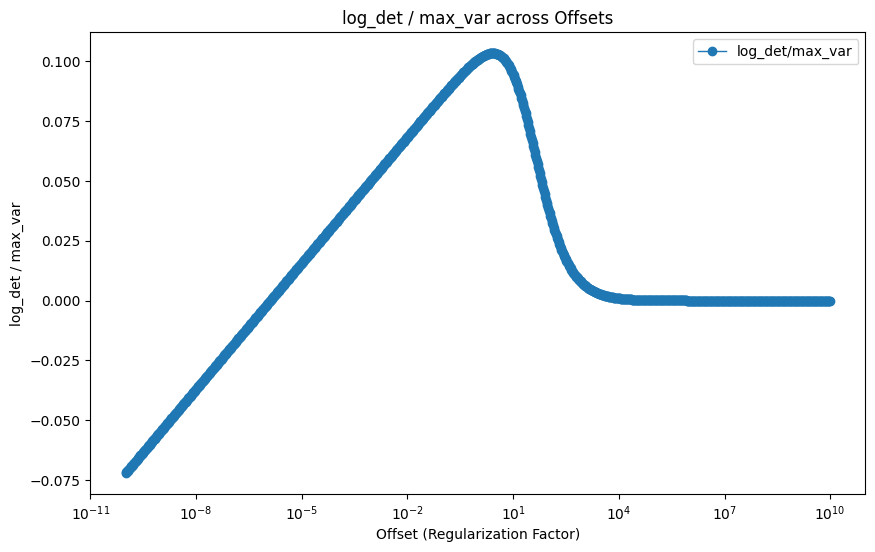

In [67]:
avg_metrics = D.groupby('offset')[['max_var', 'log_det']].mean()

avg_metrics['log_det_max_var_ratio'] = avg_metrics['log_det'] / avg_metrics['max_var']

plt.figure(figsize=(10, 6))
plt.plot(avg_metrics.index, avg_metrics['log_det_max_var_ratio'], label='log_det/max_var', marker='o', linewidth=1)

plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('log_det / max_var')
plt.title('log_det / max_var across Offsets')
plt.legend()
plt.show()